In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [4]:
url="IndianWeatherRepository.csv"
df = pd.read_csv(url)
df.head()

,country,location_name,region,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,India,Ashoknagar,Madhya Pradesh,24.57,77.72,Asia/Kolkata,1693286100,2023-08-29 10:45,27.5,81.5,...,12.6,18.5,1,2,05:59 AM,06:41 PM,05:42 PM,03:38 AM,Waxing Gibbous,93
1,India,Raisen,Madhya Pradesh,23.33,77.80,Asia/Kolkata,1693286100,2023-08-29 10:45,27.5,81.5,...,10.7,14.2,1,1,06:00 AM,06:40 PM,05:39 PM,03:41 AM,Waxing Gibbous,93
2,India,Chhindwara,Madhya Pradesh,22.07,78.93,Asia/Kolkata,1693286100,2023-08-29 10:45,26.3,79.3,...,16.8,20.7,2,2,05:56 AM,06:34 PM,05:32 PM,03:39 AM,Waxing Gibbous,93
3,India,Betul,Madhya Pradesh,21.86,77.93,Asia/Kolkata,1693286100,2023-08-29 10:45,25.6,78.1,...,4.9,6.6,1,1,06:00 AM,06:38 PM,05:36 PM,03:43 AM,Waxing Gibbous,93
4,India,Hoshangabad,Madhya Pradesh,22.75,77.72,Asia/Kolkata,1693286100,2023-08-29 10:45,27.2,81.0,...,11.4,14.8,1,1,06:01 AM,06:39 PM,05:38 PM,03:42 AM,Waxing Gibbous,93


In [5]:
df.count()

country                         118298
location_name                   118298
region                          118298
latitude                        118298
longitude                       118298
timezone                        118298
last_updated_epoch              118298
last_updated                    118298
temperature_celsius             118298
temperature_fahrenheit          118298
condition_text                  118298
wind_mph                        118298
wind_kph                        118298
wind_degree                     118298
wind_direction                  118298
pressure_mb                     118298
pressure_in                     118298
precip_mm                       118298
precip_in                       118298
humidity                        118298
cloud                           118298
feels_like_celsius              118298
feels_like_fahrenheit           118298
visibility_km                   118298
visibility_miles                118298
uv_index                 

In [8]:
features_to_keep = [
    'location_name', 'region',
    'temperature_celsius', 'humidity', 'wind_kph', 'wind_degree',
    'pressure_mb', 'precip_mm', 'cloud', 'feels_like_celsius',
    'visibility_km', 'uv_index', 'gust_kph',
    'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
    'condition_text', 'last_updated'
]

df = df[features_to_keep]
df=df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118298 entries, 0 to 118297
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_name             118298 non-null  object 
 1   region                    118298 non-null  object 
 2   temperature_celsius       118298 non-null  float64
 3   humidity                  118298 non-null  int64  
 4   wind_kph                  118298 non-null  float64
 5   wind_degree               118298 non-null  int64  
 6   pressure_mb               118298 non-null  float64
 7   precip_mm                 118298 non-null  float64
 8   cloud                     118298 non-null  int64  
 9   feels_like_celsius        118298 non-null  float64
 10  visibility_km             118298 non-null  float64
 11  uv_index                  118298 non-null  float64
 12  gust_kph                  118298 non-null  float64
 13  air_quality_PM2.5         118298 non-null  f

In [9]:
df.columns

Index(['location_name', 'region', 'temperature_celsius', 'humidity',
       'wind_kph', 'wind_degree', 'pressure_mb', 'precip_mm', 'cloud',
       'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'condition_text', 'last_updated'],
      dtype='object')

In [10]:
rain_keywords = ['rain', 'drizzle', 'shower', 'thunder', 'sleet']

df['RainToday'] = df['condition_text'].str.lower().apply(
    lambda x: 'Yes' if any(k in x for k in rain_keywords) else 'No'
)

df['RainToday'].value_counts()

RainToday
No     106280
Yes     12018
Name: count, dtype: int64

In [12]:
# Focus on major cities with enough data
selected_cities = ['Mumbai', 'Kolkata', 'Delhi', 'Bengaluru', 'Chennai']
df = df[df['location_name'].isin(selected_cities)]
print(f"Records after filtering: {len(df)}")
df['location_name'].value_counts()

Records after filtering: 729


location_name
Kolkata    271
Mumbai     242
Chennai    216
Name: count, dtype: int64

In [14]:
def date_to_season(date):
    month = date.month
    if month in [3, 4, 5]:
        return 'Summer'        # Hot & dry
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'       # Heavy rainfall
    elif month in [10, 11]:
        return 'Post-Monsoon'  # Retreating monsoon
    else:
        return 'Winter'   

In [15]:
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['Season'] = df['last_updated'].apply(date_to_season)
df = df.drop(columns=['last_updated', 'condition_text', 'precip_mm'])
df.head()

,location_name,region,temperature_celsius,humidity,wind_kph,wind_degree,pressure_mb,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,RainToday,Season
289,Kolkata,West Bengal,34.0,60,11.2,300,1004.0,50,38.3,3.2,8.0,12.2,182.7,229.6,5,No,Monsoon
367,Mumbai,Maharashtra,27.0,84,13.0,260,1010.0,75,29.6,2.5,6.0,15.1,16.3,23.7,2,Yes,Monsoon
488,Chennai,Tamil Nadu,30.0,89,9.0,300,1008.0,75,33.9,4.0,7.0,10.1,5.9,10.9,1,No,Monsoon
832,Kolkata,West Bengal,30.0,84,11.2,320,1005.0,75,32.5,2.0,8.0,2.5,242.6,315.0,5,No,Monsoon
912,Mumbai,Maharashtra,28.0,89,6.8,140,1010.0,50,32.4,2.5,7.0,10.8,38.2,56.1,2,No,Monsoon


In [16]:
X = df.drop(columns='RainToday', axis=1)
y = df['RainToday']

In [17]:
y.value_counts()

RainToday
No     668
Yes     61
Name: count, dtype: int64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

In [19]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()  
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [20]:
# Scale the numeric features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# One-hot encode the categoricals 
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [22]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [23]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [25]:
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['temperature_celsius',
                                                                          'humidity',
                                                                          'wind_kph',
                                                                          'wind_degree',
                                                                          'pressure_mb',
                                                                          'cloud',
                                                                          'feels_like_celsius',
                                                                          'visibility_km',
                                                                          'uv_index',
                                                                          'gust_kph',
                                                                          'air_qua...
                                                                          'air_quality_us-epa-index']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['location_name',
                                                                          'region',
                                                                          'Season'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

In [26]:
print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))


Best parameters found:  {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Best cross-validation score: 0.94


In [27]:
test_score = grid_search.score(X_test, y_test)  
print("Test set score: {:.2f}".format(test_score))

Test set score: 0.95


In [28]:
y_pred = grid_search.predict(X_test)
y_pred

array(['No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes',
       'No', 'No', 'No', 'No'], dtype=object)

In [29]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

          No       0.96      0.99      0.97       134
         Yes       0.78      0.58      0.67        12

    accuracy                           0.95       146
   macro avg       0.87      0.78      0.82       146
weighted avg       0.95      0.95      0.95       146



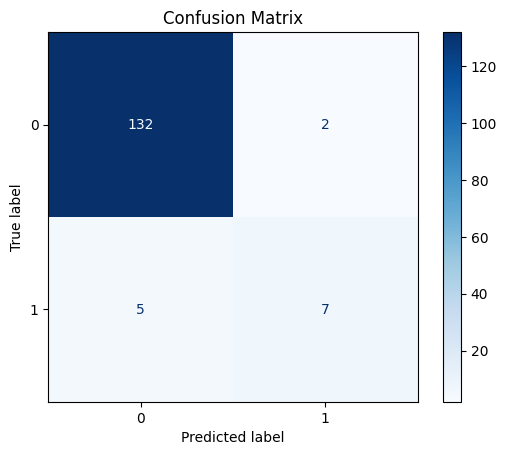

In [30]:
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [31]:
feature_importances = grid_search.best_estimator_['classifier'].feature_importances_


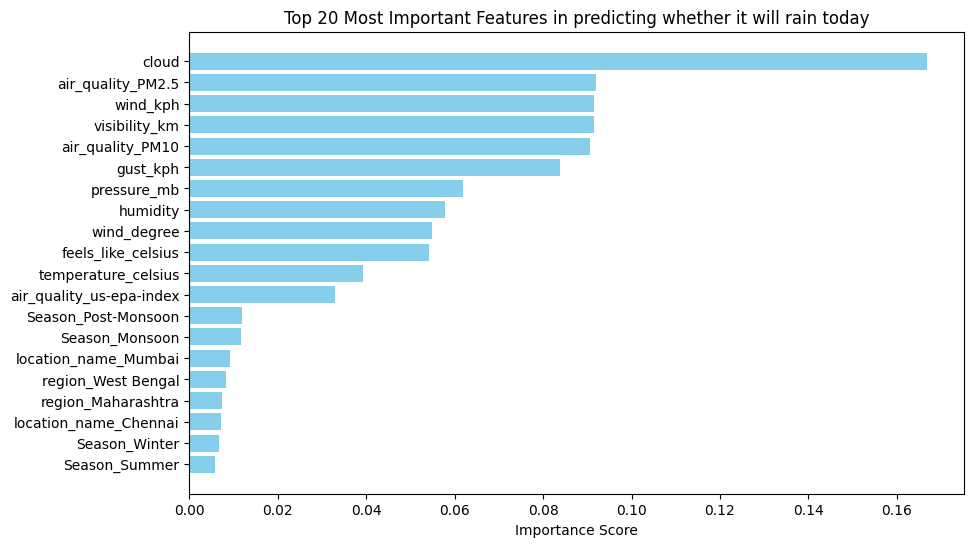

In [32]:
# Combine numeric and categorical feature names
feature_names = numeric_features + list(grid_search.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

N = 20  # Change this number to display more or fewer features
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.title(f'Top {N} Most Important Features in predicting whether it will rain today')
plt.xlabel('Importance Score')
plt.show()

In [33]:
# Replace RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# update the model's estimator to use the new pipeline
grid_search.estimator = pipeline

# Define a new grid with Logistic Regression parameters
param_grid = {
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

grid_search.param_grid = param_grid

# Fit the updated pipeline with LogisticRegression
grid_search.fit(X_train, y_train)

# Make predictions
y_pred = grid_search.predict(X_test)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

              precision    recall  f1-score   support

          No       0.96      0.96      0.96       134
         Yes       0.50      0.50      0.50        12

    accuracy                           0.92       146
   macro avg       0.73      0.73      0.73       146
weighted avg       0.92      0.92      0.92       146



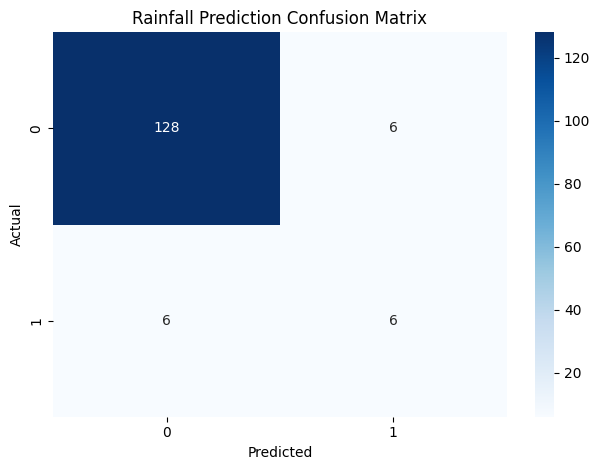

In [49]:
print(classification_report(y_test, y_pred))

# Generate the confusion matrix 
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labelsm
plt.title('Rainfall Prediction Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

In [50]:
print(X_train.columns.tolist())

['location_name', 'region', 'temperature_celsius', 'humidity', 'wind_kph', 'wind_degree', 'pressure_mb', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'Season']


In [51]:
import joblib
joblib.dump(grid_search, 'model.pkl')

['model.pkl']